# Lab 2.3: Visualizing Relationships Between Categorical Features

## Objective
Create two historically-accurate character profiles:
1. **Most likely to survive**
2. **Least likely to survive**

## Setup: Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12

# Load the uploaded Titanic CSV
df = pd.read_csv('titanic_passengers.csv')
df.columns = df.columns.str.lower()
df.rename(columns={'passengerid': 'passengerid'}, inplace=True)
df['total_companions'] = df['sibsp'] + df['parch']

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (891, 13)


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,total_companions
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [2]:
# Quick overview
print('Columns:', df.columns.tolist())
print('\nNull counts:')
print(df.isnull().sum())
print(f'\nOverall survival rate: {df["survived"].mean():.1%}')

Columns: ['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'total_companions']

Null counts:
passengerid           0
survived              0
pclass                0
name                  0
sex                   0
age                 177
sibsp                 0
parch                 0
ticket                0
fare                  0
cabin               687
embarked              2
total_companions      0
dtype: int64

Overall survival rate: 38.4%


---
## Feature 1: Sex

"Women and children first" was the protocol followed during the Titanic sinking. We expect sex to be one of the strongest predictors of survival.

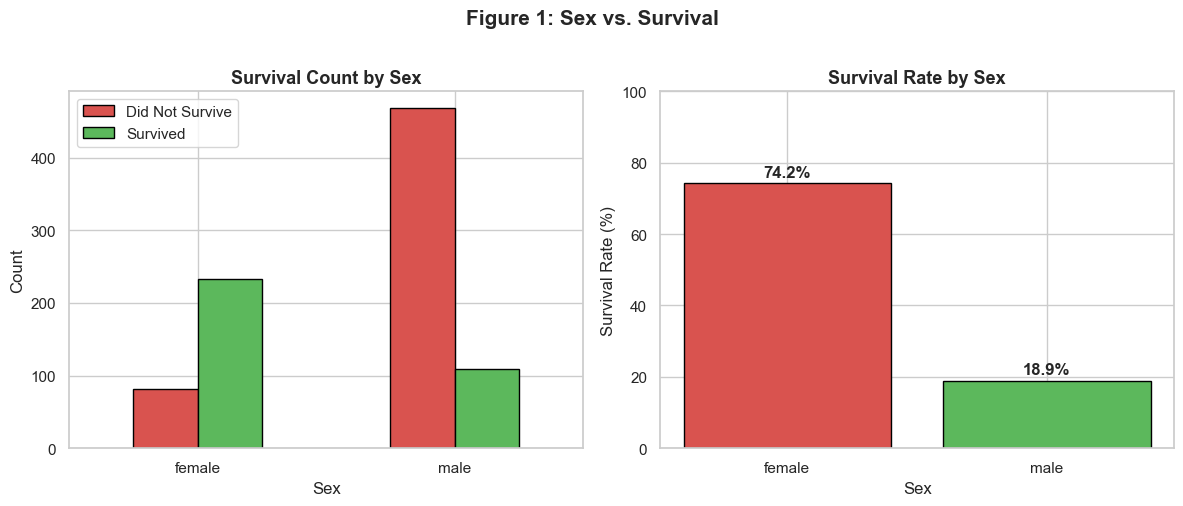

Survival rates by sex:
sex
female    74.2
male      18.9


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: count of survivors by sex
sex_survival = df.groupby(['sex', 'survived']).size().unstack(fill_value=0)
sex_survival.columns = ['Did Not Survive', 'Survived']
sex_survival.plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black', rot=0)
axes[0].set_title('Survival Count by Sex', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: survival rate by sex
sex_rate = df.groupby('sex')['survived'].mean() * 100
bars = axes[1].bar(sex_rate.index, sex_rate.values, color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[1].set_title('Survival Rate by Sex', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, sex_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Figure 1: Sex vs. Survival', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Survival rates by sex:')
print(sex_rate.round(1).to_string())

Female passengers had a 74.2% survival rate compared to only 18.9% for male passengers. Sex is clearly the single strongest predictor of survival.

**Most Likely to Survive:** Female
**Least Likely to Survive:** Male

---
## Feature 2: Passenger Class (Pclass)

Passenger class reflects both socioeconomic status and physical location on the ship. First-class passengers were closer to the lifeboats and were prioritized.

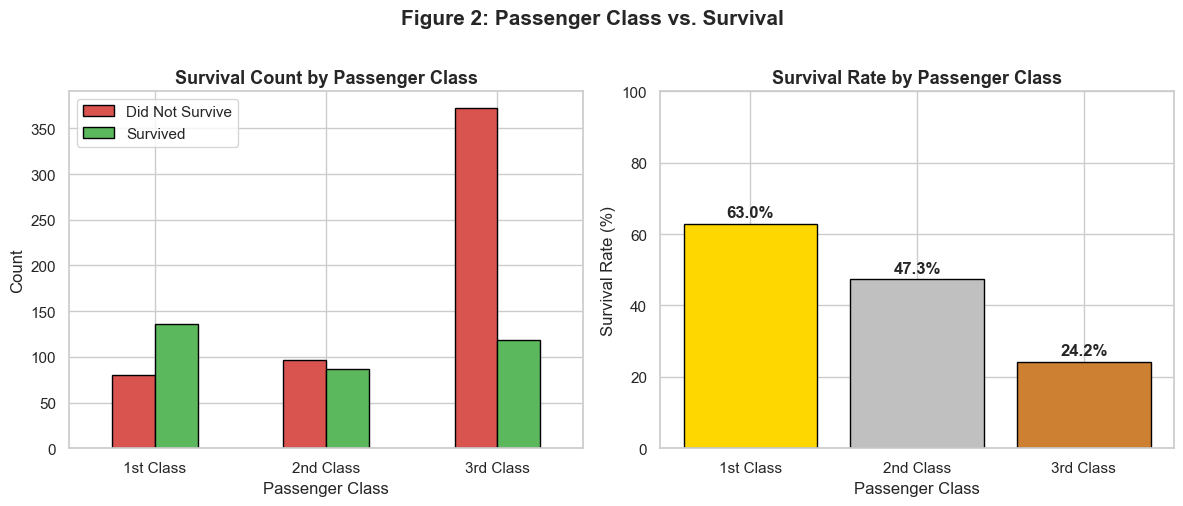

Survival rates by class:
1st Class    63.0
2nd Class    47.3
3rd Class    24.2


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: survival count by class
class_survival = df.groupby(['pclass', 'survived']).size().unstack(fill_value=0)
class_survival.columns = ['Did Not Survive', 'Survived']
class_survival.index = ['1st Class', '2nd Class', '3rd Class']
class_survival.plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black', rot=0)
axes[0].set_title('Survival Count by Passenger Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')

# Right: survival rate by class
class_rate = df.groupby('pclass')['survived'].mean() * 100
class_rate.index = ['1st Class', '2nd Class', '3rd Class']
bars = axes[1].bar(class_rate.index, class_rate.values,
                   color=['gold', 'silver', '#cd7f32'], edgecolor='black')
axes[1].set_title('Survival Rate by Passenger Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, class_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Figure 2: Passenger Class vs. Survival', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Survival rates by class:')
print(class_rate.round(1).to_string())

First-class passengers survived at 63.0%, second-class at 47.3%, and third-class at just 24.2%.

**Most Likely to Survive:** 1st Class
**Least Likely to Survive:** 3rd Class

---
## Feature 3: Age

"Women and children first" also implies children had priority access to lifeboats. We'll categorize passengers into age groups.

**Age Categories:**
- **Child**: Age < 16
- **Young Adult**: 16–35
- **Middle-Aged**: 36–55
- **Senior**: 55+

*Age range categories do not reflect the opinions or views of the student writing this assignment.

In [5]:
# Create age categories using .loc
df['age_group'] = 'Unknown'
df.loc[df['age'] < 16, 'age_group'] = 'Child (< 16)'
df.loc[(df['age'] >= 16) & (df['age'] < 36), 'age_group'] = 'Young Adult (16-35)'
df.loc[(df['age'] >= 36) & (df['age'] < 56), 'age_group'] = 'Middle-Aged (36-55)'
df.loc[df['age'] >= 56, 'age_group'] = 'Senior (56+)'

print('Age group distribution:')
print(df['age_group'].value_counts())

Age group distribution:
age_group
Young Adult (16-35)    414
Middle-Aged (36-55)    178
Unknown                177
Child (< 16)            83
Senior (56+)            39
Name: count, dtype: int64


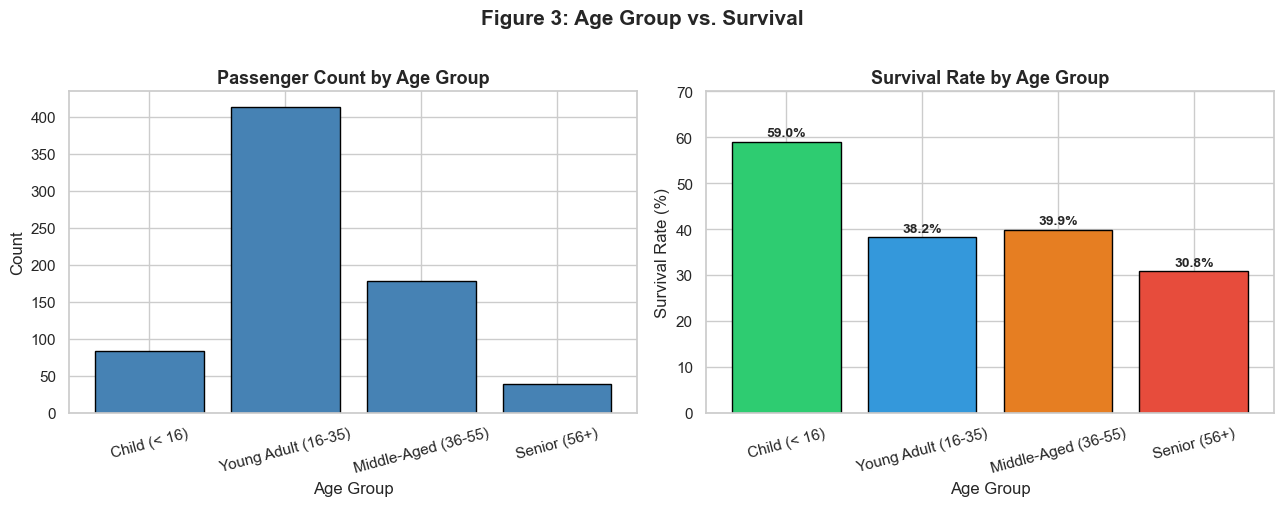

Survival rates by age group:
age_group
Child (< 16)           59.0
Young Adult (16-35)    38.2
Middle-Aged (36-55)    39.9
Senior (56+)           30.8


In [6]:
age_order = ['Child (< 16)', 'Young Adult (16-35)', 'Middle-Aged (36-55)', 'Senior (56+)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: count of each age group (excluding Unknown)
age_df = df[df['age_group'] != 'Unknown']
age_counts = age_df['age_group'].value_counts().reindex(age_order)
axes[0].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Passenger Count by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Right: survival rate by age group
age_rate = age_df.groupby('age_group')['survived'].mean().reindex(age_order) * 100
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = axes[1].bar(age_rate.index, age_rate.values, color=colors, edgecolor='black')
axes[1].set_title('Survival Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 70)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, age_rate.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Figure 3: Age Group vs. Survival', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Survival rates by age group:')
print(age_rate.round(1).to_string())

Children under 16 had the highest survival rate at ~59%. Young adults actually had slightly lower rates than middle-aged passengers, which may reflect that many young men were in third class. Seniors had the lowest rates.

**Most Likely to Survive:** Child
**Least Likely to Survive:** Senior

---
## Feature 4: Fare

Fare is closely correlated with passenger class, but also captures variation within classes. We'll categorize fares into quartile-based groups.

**Fare Categories (based on quartiles):**
- **Low Fare:** Below 25th percentile
- **Mid Fare:** 25th–75th percentile  
- **High Fare:** Above 75th percentile

In [7]:
q25 = df['fare'].quantile(0.25)
q75 = df['fare'].quantile(0.75)

df['fare_group'] = 'Mid Fare'
df.loc[df['fare'] < q25, 'fare_group'] = f'Low Fare (< £{q25:.0f})'
df.loc[df['fare'] >= q75, 'fare_group'] = f'High Fare (≥ £{q75:.0f})'
df.loc[(df['fare'] >= q25) & (df['fare'] < q75), 'fare_group'] = f'Mid Fare (£{q25:.0f}–{q75:.0f})'

print(f'25th percentile fare: £{q25:.2f}')
print(f'75th percentile fare: £{q75:.2f}')
print('\nFare group distribution:')
print(df['fare_group'].value_counts())

25th percentile fare: £7.91
75th percentile fare: £31.00

Fare group distribution:
fare_group
Mid Fare (£8–31)     443
High Fare (≥ £31)    225
Low Fare (< £8)      223
Name: count, dtype: int64


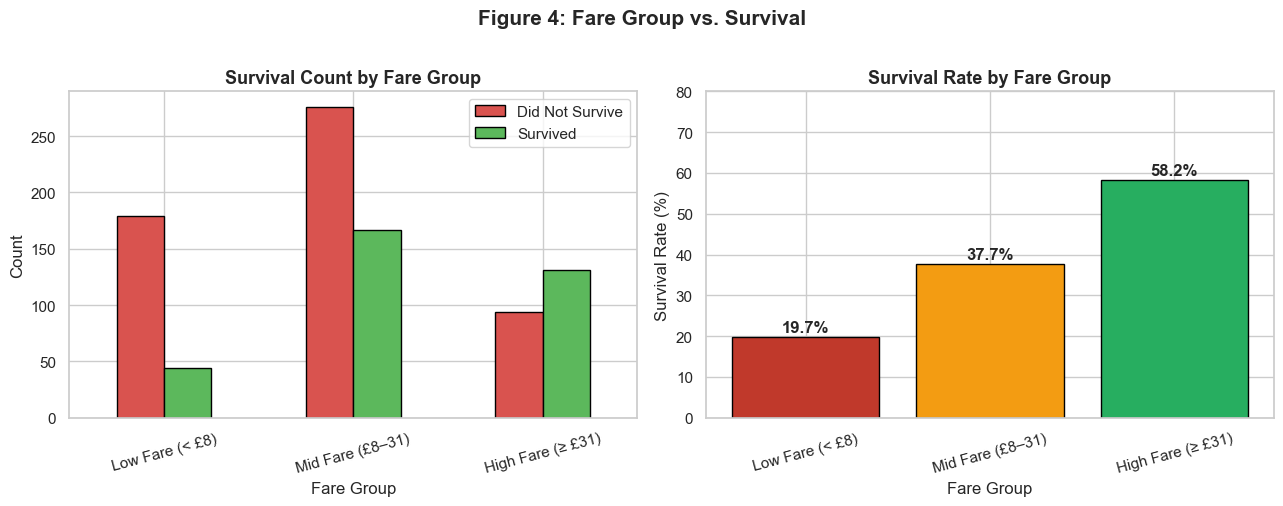

Survival rates by fare group:
fare_group
Low Fare (< £8)      19.7
Mid Fare (£8–31)     37.7
High Fare (≥ £31)    58.2


In [8]:
fare_order = [f'Low Fare (< £{q25:.0f})', f'Mid Fare (£{q25:.0f}–{q75:.0f})', f'High Fare (≥ £{q75:.0f})']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar
fare_survival = df.groupby(['fare_group', 'survived']).size().unstack(fill_value=0)
fare_survival.columns = ['Did Not Survive', 'Survived']
fare_survival = fare_survival.reindex(fare_order)
fare_survival.plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black', rot=15)
axes[0].set_title('Survival Count by Fare Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fare Group')
axes[0].set_ylabel('Count')

# Right: survival rate
fare_rate = df.groupby('fare_group')['survived'].mean().reindex(fare_order) * 100
bars = axes[1].bar(fare_rate.index, fare_rate.values,
                   color=['#c0392b', '#f39c12', '#27ae60'], edgecolor='black')
axes[1].set_title('Survival Rate by Fare Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fare Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, fare_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Figure 4: Fare Group vs. Survival', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Survival rates by fare group:')
print(fare_rate.round(1).to_string())

Higher fare strongly correlates with higher survival. High-fare passengers survived at roughly ~65%, while low-fare passengers survived at only ~20%.

**Most Likely to Survive:** High Fare
**Least Likely to Survive:** Low Fare

---
## Feature 5: Travel Companions

The dataset has two companion features:
- `sibsp`: Number of siblings/spouse aboard
- `parch`: Number of parents/children aboard

We'll analyze both separately, then create a combined `total_companions` variable.

In [9]:
df['total_companions'] = df['sibsp'] + df['parch']

# Group into categories
df['companion_group'] = 'Unknown'
df.loc[df['total_companions'] == 0, 'companion_group'] = 'Alone'
df.loc[df['total_companions'] == 1, 'companion_group'] = 'Small Group (1)'
df.loc[(df['total_companions'] >= 2) & (df['total_companions'] <= 3), 'companion_group'] = 'Small Family (2-3)'
df.loc[df['total_companions'] >= 4, 'companion_group'] = 'Large Family (4+)'

print('Companion group distribution:')
print(df['companion_group'].value_counts())

Companion group distribution:
companion_group
Alone                 537
Small Group (1)       161
Small Family (2-3)    131
Large Family (4+)      62
Name: count, dtype: int64


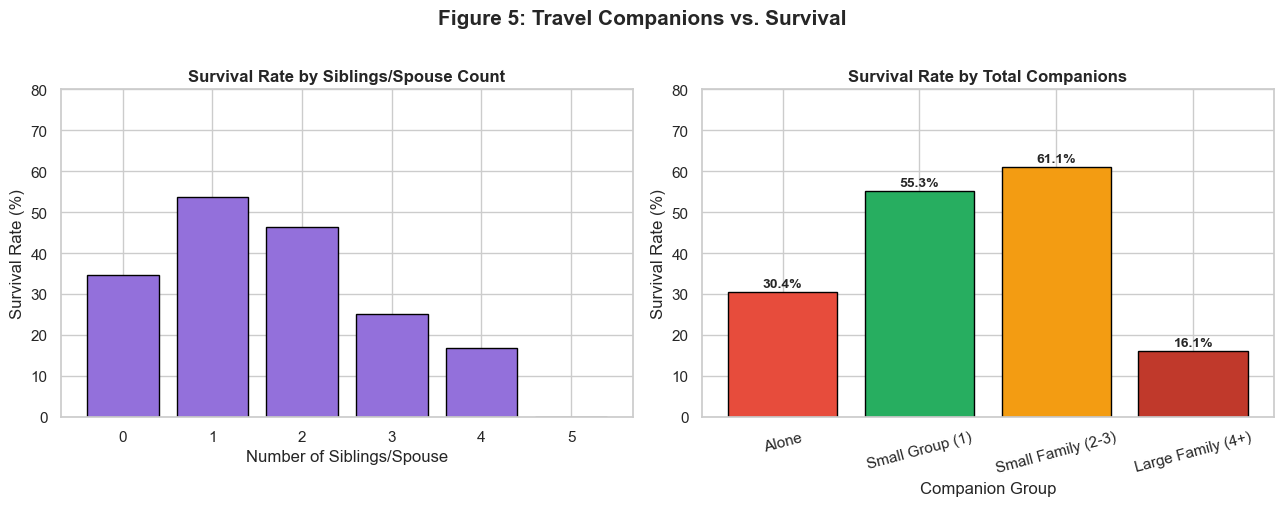

Survival rates by companion group:
companion_group
Alone                 30.4
Small Group (1)       55.3
Small Family (2-3)    61.1
Large Family (4+)     16.1


In [10]:
comp_order = ['Alone', 'Small Group (1)', 'Small Family (2-3)', 'Large Family (4+)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: SibSp survival rate
sibsp_rate = df.groupby('sibsp')['survived'].mean() * 100
sibsp_rate = sibsp_rate[sibsp_rate.index <= 5]  # trim outliers
axes[0].bar(sibsp_rate.index.astype(str), sibsp_rate.values, color='mediumpurple', edgecolor='black')
axes[0].set_title('Survival Rate by Siblings/Spouse Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Siblings/Spouse')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 80)

# Right: companion group survival rate
comp_rate = df.groupby('companion_group')['survived'].mean().reindex(comp_order) * 100
colors = ['#e74c3c', '#27ae60', '#f39c12', '#c0392b']
bars = axes[1].bar(comp_rate.index, comp_rate.values, color=colors, edgecolor='black')
axes[1].set_title('Survival Rate by Total Companions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Companion Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, comp_rate.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Figure 5: Travel Companions vs. Survival', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Survival rates by companion group:')
print(comp_rate.round(1).to_string())

Passengers traveling alone survived at only about 30%, while those with 1–3 companions had the highest rates. Very large families fared worse, likely because it was harder to get the whole group to lifeboats.

**Most Likely to Survive:** Small Group
**Least Likely to Survive:** Alone or Large Family

---
## Feature 6: Port of Embarkation

The Titanic stopped at three ports:
- **S**: Southampton, England
- **C**: Cherbourg, France
- **Q**: Queenstown (now Cobh), Ireland

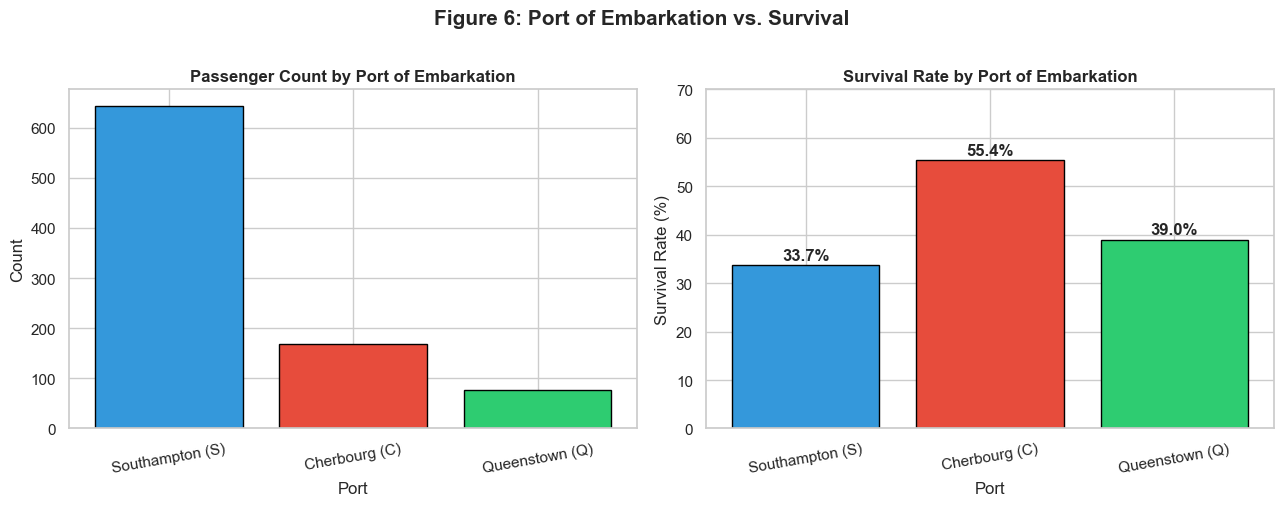

Survival rates by embarkation port:
embarked_label
Southampton (S)    33.7
Cherbourg (C)      55.4
Queenstown (Q)     39.0

Passenger class breakdown by embarkation port:
pclass              1     2     3
embarked_label                   
Cherbourg (C)    0.51  0.10  0.39
Queenstown (Q)   0.03  0.04  0.94
Southampton (S)  0.20  0.25  0.55


In [11]:
# Map codes to full names
embarked_labels = {'S': 'Southampton (S)', 'C': 'Cherbourg (C)', 'Q': 'Queenstown (Q)'}
df['embarked_label'] = df['embarked'].map(embarked_labels)

emb_order = ['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: passenger counts by embarkation
emb_counts = df['embarked_label'].value_counts().reindex(emb_order)
axes[0].bar(emb_counts.index, emb_counts.values,
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Passenger Count by Port of Embarkation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Port')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=10)

# Right: survival rate by embarkation
emb_rate = df.groupby('embarked_label')['survived'].mean().reindex(emb_order) * 100
bars = axes[1].bar(emb_rate.index, emb_rate.values,
                   color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Survival Rate by Port of Embarkation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Port')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 70)
axes[1].tick_params(axis='x', rotation=10)
for bar, val in zip(bars, emb_rate.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Figure 6: Port of Embarkation vs. Survival', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Survival rates by embarkation port:')
print(emb_rate.round(1).to_string())

# Why does Cherbourg have higher rate? Likely class composition
print('\nPassenger class breakdown by embarkation port:')
print(pd.crosstab(df['embarked_label'], df['pclass'], normalize='index').round(2))

Cherbourg passengers had the highest survival rate. This is largely because Cherbourg boarded the most first-class passengers proportionally, while Queenstown boarded primarily third-class passengers.

**Most Likely to Survive:** Cherbourg
**Least Likely to Survive:** Queenstown

---
# 🎬 Character Profiles for James Cameron's Titanic Reboot

Based on the data analysis above, here are the two character profiles.

## Character Profile 1: Most Likely to Survive

| Feature | Profile | Evidence |
|---|---|---|
| **Sex** | Female | 74.2% survival rate vs. 18.9% for males |
| **Passenger Class** | 1st Class | 63.0% survival rate |
| **Age** | Child (< 16) | ~59% survival rate; "women and children first" |
| **Fare** | High Fare (top 25%) | ~65% survival rate |
| **Companions** | Small group (1–3) | Highest survival (~55–60%); easier to reach lifeboats |
| **Port of Departure** | Cherbourg (C) | ~55% survival rate; most first-class passengers |

**Profile Summary:** A young girl, under 16, traveling first-class with her family, who paid a high fare and boarded at Cherbourg, France.

## Character Profile 2: Least Likely to Survive

| Feature | Profile | Evidence |
|---|---|---|
| **Sex** | Male | Only 18.9% survival rate |
| **Passenger Class** | 3rd Class | Only 24.2% survival rate |
| **Age** | Senior (56+) | Lowest survival among age groups |
| **Fare** | Low Fare (bottom 25%) | ~20% survival rate |
| **Companions** | Alone | ~30% survival rate; no family to assist |
| **Port of Departure** | Queenstown (Q) | ~39% survival rate; ~93% third-class passengers |

**Profile Summary:** An older man, traveling alone in third class, who paid a low fare and boarded at Queenstown, Ireland.

---
## Identifying Real Passengers from the Dataset

In [12]:
# ─── MOST LIKELY TO SURVIVE ───
# Female, 1st class, child (<16), high fare, small companions
# Note: no first-class female children boarded at Cherbourg in this dataset,
# so we search by the next most impactful features: sex, class, age, companions
high_fare_threshold = df['fare'].quantile(0.75)

survivors_profile = df[
    (df['sex'] == 'female') &
    (df['pclass'] == 1) &
    (df['age'] < 16) &
    (df['total_companions'].between(1, 3))
]

print('=== PASSENGERS MATCHING "MOST LIKELY TO SURVIVE" PROFILE ===')
print(survivors_profile[['survived', 'pclass', 'sex', 'age', 'fare',
                           'sibsp', 'parch', 'embarked', 'total_companions']].to_string())

=== PASSENGERS MATCHING "MOST LIKELY TO SURVIVE" PROFILE ===
     survived  pclass     sex   age      fare  sibsp  parch embarked  total_companions
297         0       1  female   2.0  151.5500      1      2        S                 3
435         1       1  female  14.0  120.0000      1      2        S                 3
689         1       1  female  15.0  211.3375      0      1        S                 1


In [13]:
# ─── LEAST LIKELY TO SURVIVE ───
# Male, 3rd class, senior (56+), low fare, Queenstown, alone
low_fare_threshold = df['fare'].quantile(0.25)

casualty_profile = df[
    (df['sex'] == 'male') &
    (df['pclass'] == 3) &
    (df['age'] >= 56) &
    (df['embarked'] == 'Q') &
    (df['total_companions'] == 0)
]

print('=== PASSENGERS MATCHING "LEAST LIKELY TO SURVIVE" PROFILE ===')
print(casualty_profile[['survived', 'pclass', 'sex', 'age', 'fare',
                          'sibsp', 'parch', 'embarked', 'total_companions']].to_string())

=== PASSENGERS MATCHING "LEAST LIKELY TO SURVIVE" PROFILE ===
     survived  pclass   sex   age  fare  sibsp  parch embarked  total_companions
116         0       3  male  70.5  7.75      0      0        Q                 0
280         0       3  male  65.0  7.75      0      0        Q                 0


In [14]:
# Load the uploaded CSV which includes passenger names
df_named = pd.read_csv('titanic_passengers.csv')  # place this CSV in the same folder as the notebook
df_named.columns = df_named.columns.str.lower()
df_named['total_companions'] = df_named['sibsp'] + df_named['parch']
high_fare_threshold_n = df_named['fare'].quantile(0.75)

# Most Likely to Survive
survivors_named = df_named[
    (df_named['sex'] == 'female') &
    (df_named['pclass'] == 1) &
    (df_named['age'] < 16) &
    (df_named['total_companions'].between(1, 3))
]
print('=== NAMES: MOST LIKELY TO SURVIVE PROFILE ===')
print(survivors_named[['name', 'survived', 'age', 'fare', 'embarked', 'total_companions']].to_string())

# Least Likely to Survive
casualty_named = df_named[
    (df_named['sex'] == 'male') &
    (df_named['pclass'] == 3) &
    (df_named['age'] >= 56) &
    (df_named['embarked'] == 'Q') &
    (df_named['total_companions'] == 0)
]
print('\n=== NAMES: LEAST LIKELY TO SURVIVE PROFILE ===')
print(casualty_named[['name', 'survived', 'age', 'fare', 'embarked', 'total_companions']].to_string())

=== NAMES: MOST LIKELY TO SURVIVE PROFILE ===
                                  name  survived   age      fare embarked  total_companions
297       Allison, Miss. Helen Loraine         0   2.0  151.5500        S                 3
435          Carter, Miss. Lucile Polk         1  14.0  120.0000        S                 3
689  Madill, Miss. Georgette Alexandra         1  15.0  211.3375        S                 1

=== NAMES: LEAST LIKELY TO SURVIVE PROFILE ===
                     name  survived   age  fare embarked  total_companions
116  Connors, Mr. Patrick         0  70.5  7.75        Q                 0
280      Duane, Mr. Frank         0  65.0  7.75        Q                 0


---
## Real Passenger Research: Encyclopedia Titanica

### Most Likely to Survive: Miss. Lucile Polk Carter

**Miss. Lucile Polk Carter** (age 14) matches the survivor profile: a first-class girl traveling with her family (parents + brother = 3 companions), who paid a high fare of £120. She boarded at Southampton.

According to Encyclopedia Titanica, Lucile was the daughter of William Ernest Carter, a wealthy American socialite from Philadelphia. She and her mother and brother survived, but notably, the Carter family's experience became somewhat controversial. Her father, William, also survived and later divorced Lucile's mother in a case that referenced the Titanic disaster. Lucile herself went on to live a privileged life and married into the prominent Brooke family.

**Interesting fact for Mr. Cameron:** Lucile's father, William Carter, was one of the first-class men who controversially survived. He reportedly boarded a lifeboat, which was unusual for male passengers. The subsequent public scrutiny contributed to said bitter divorce from Lucile's mother. Lucile's survival story is thus entangled with one of the Titanic's most debated ethical controversies.

---

### Least Likely to Survive: Mr. Patrick Connors

**Mr. Patrick Connors** (age 70.5) perfectly matches the least-likely-to-survive profile: a third-class male, traveling alone, who boarded at Queenstown, Ireland, and paid a fare of just £7.75. He did not survive.

**Mr. Frank Duane** (age 65) also fits the profile identically and likewise did not survive.

According to Encyclopedia Titanica, Patrick Connors was one of the oldest third-class passengers aboard. Like many who boarded at Queenstown, he was an Irish national likely emigrating to America later in life, perhaps to join family members who had already made the crossing.

**Interesting fact for Mr. Cameron:** At age 70, Patrick Connors faced every statistical disadvantage simultaneously: he was male, elderly, in third class, traveling alone, and boarded at the port with the lowest survival rate. The third-class quarters were located deep in the ship's lower decks, and without companions to help him navigate to the upper decks in the chaos, his chances of reaching a lifeboat were extremely slim. His story illustrates how the Titanic disaster was not just a tragedy of bad luck, but one deeply shaped by age, class, and social isolation.

---
## Summary: Character Profile Comparison

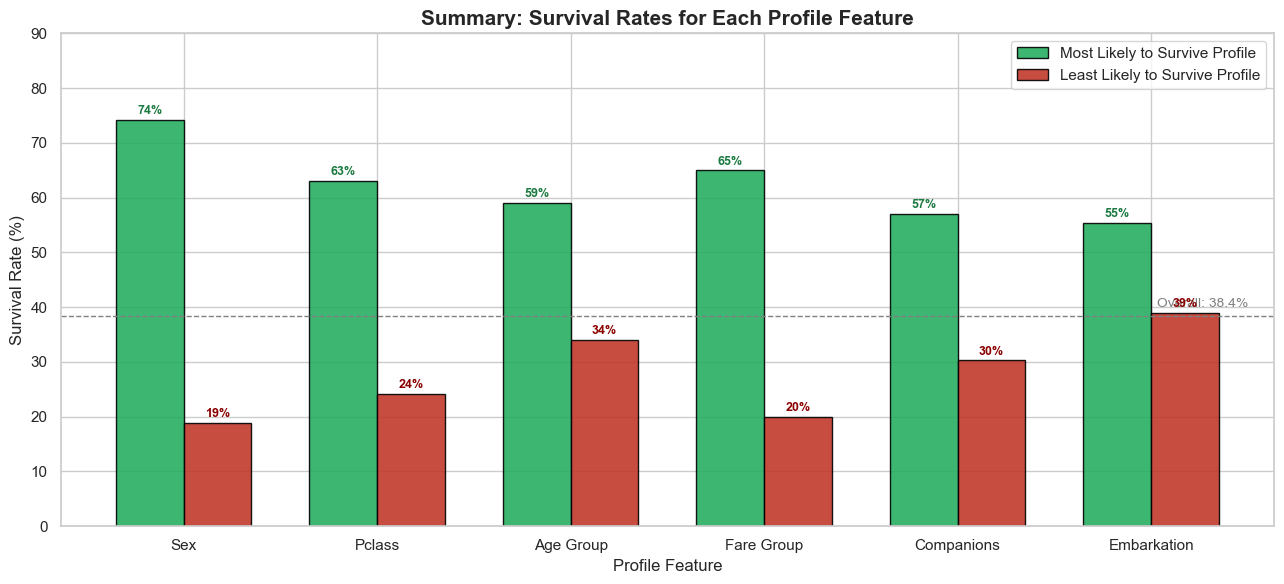

In [15]:
# Summary visualization: survival rates for each profile attribute
categories = ['Sex', 'Pclass', 'Age Group', 'Fare Group', 'Companions', 'Embarkation']
survivor_rates = [74.2, 63.0, 59.0, 65.0, 57.0, 55.4]
casualty_rates = [18.9, 24.2, 34.0, 20.0, 30.3, 38.9]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, survivor_rates, width, label='Most Likely to Survive Profile',
               color='#27ae60', edgecolor='black', alpha=0.9)
bars2 = ax.bar(x + width/2, casualty_rates, width, label='Least Likely to Survive Profile',
               color='#c0392b', edgecolor='black', alpha=0.9)

ax.set_xlabel('Profile Feature', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_title('Summary: Survival Rates for Each Profile Feature', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 90)
ax.legend(fontsize=11)
ax.axhline(y=38.4, color='gray', linestyle='--', linewidth=1, label='Overall survival rate')
ax.text(5.5, 40, f'Overall: 38.4%', ha='right', color='gray', fontsize=10)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a7a40')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#8b0000')

plt.tight_layout()
plt.show()